In [272]:
from ml_enhance import load_hpc_result, compare, CorrelationFilter, FeatureImportance
from math import floor
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
from dataclasses import dataclass
import numpy as np
import json

In [273]:
@dataclass
class ModelConfig:
    mean_col: str
    std_col: str
    label: str
    color: str
    marker: str = "o"
    zorder: int = 3

In [274]:
def combine_model_dfs(model_dfs: dict[str, pd.DataFrame], metric: str) -> pd.DataFrame:
    """
    Combines per-model DataFrames into a single wide DataFrame with mean/std per model.

    Args:
        model_dfs: dict mapping model name to its DataFrame.

    Returns:
        Wide DataFrame with num_samples + {name}_mean + {name}_std columns.
    """
    n_tot = 8759 # 8763 before rerun
    n_train = floor(n_tot * (4/5))
    
    agg_dfs = []
    for name, df in model_dfs.items():
        agg = (
            df.groupby("size")[metric]
            .agg(mean="mean", std="std", count="count")
            .reset_index()
            .rename(columns={
                "mean": f"{name}_mean",
                "std": f"{name}_std",
                "count": f"{name}_count",
            })
        )

        agg_dfs.append(agg)

    combined = agg_dfs[0]
    for agg in agg_dfs[1:]:
        combined = combined.merge(agg, on="size")
    
    combined.insert(1, "num_samples", combined["size"].apply(lambda size: size * n_train))

    return combined

In [300]:
def plot_size_evo(ax: plt.Axes, df: pd.DataFrame, models: list[ModelConfig]) -> None:
    for model in models:
        ax.errorbar(
            df["num_samples"],
            df[model.mean_col],
            yerr=df[model.std_col],
            fmt="none",
            ecolor=model.color,
            capsize=4,
            alpha=0.8,
            zorder=1,
        )

    for model in models:
        sns.scatterplot(
            ax=ax,
            data=df,
            x="num_samples",
            y=model.mean_col,
            color=model.color,
            s=80,
            label=model.label,
            zorder=model.zorder,
            marker=model.marker,
        )

    ax.tick_params(axis="both", labelsize=14)
    
    ax.set_xlabel("Number of training samples", fontsize=18)
    ax.set_ylabel(r"Test R$^2$", fontsize=18)

In [276]:
def remove_neg_r2(combo_df: pd.DataFrame, topo_df: pd.DataFrame, print_dropped: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    num_negs_combo = set(combo_df.index[combo_df["test_r2"] < 0])
    num_negs_topo = set(topo_df.index[topo_df["test_r2"] < 0])

    neg_nums = list(num_negs_combo | num_negs_topo)

    if print_dropped:
        for fold_id, size in combo_df.loc[neg_nums, ["fold_id", "size"]].values:
            print(f"Sample with {fold_id = :.0f} and {size = :.2f} was dropped due to negative 'test_r2'.")

    return combo_df.drop(neg_nums), topo_df.drop(neg_nums)

In [277]:
HuberReg_combo_df = load_hpc_result(Path("../data/HuberReg_results/2_HuberReg_combo_rerun_results.pkl"), "HuberReg_topo+QM", id_as_index=False)
HuberReg_topo_df = load_hpc_result(Path("../data/HuberReg_results/2_HuberReg_topo_rerun_results.pkl"), "HuberReg_topo", id_as_index=False)
HuberReg_combo_df_pos, HuberReg_topo_df_pos = remove_neg_r2(HuberReg_combo_df, HuberReg_topo_df, print_dropped=False)


KRR_combo_df = load_hpc_result(Path("../data/KRR_results/2_KRR_combo_rerun_results.pkl"), "KRR_topo+QM", id_as_index=False)
KRR_topo_df = load_hpc_result(Path("../data/KRR_results/2_KRR_topo_rerun_results.pkl"), "KRR_topo", id_as_index=False)
KRR_combo_df_pos, KRR_topo_df_pos = remove_neg_r2(KRR_combo_df, KRR_topo_df, print_dropped=False)


chemprop_baseline_df = pd.read_json("../data/chemprop_results/2_chemprop_no_added_w_charge_rerun_results.json")
chemprop_rdkit_df = pd.read_json("../data/chemprop_results/2_chemprop_w_rdkit_rerun_results.json")
chemprop_atom_df = pd.read_json("../data/chemprop_results/2_chemprop_atom_feat_rerun_results.json")
chemprop_full_df = pd.read_json("../data/chemprop_results/2_chemprop_full_feat_rerun_results.json")

In [281]:
HuberReg_combo_df[HuberReg_combo_df["test_r2"] < 0]

,fold_id,size,estimator,train_r2,test_r2,train_MSE,test_MSE,name
0,0,0.025,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.983587,-3.607693e+01,0.083159,1.963223e+02,HuberReg_topo+QM
1,0,0.050,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.935443,-6.679987e+30,0.338331,3.537053e+31,HuberReg_topo+QM
2,0,0.075,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.907818,-3.616000e+47,0.477561,1.914672e+48,HuberReg_topo+QM
3,0,0.150,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.881194,-3.945257e+19,0.626961,2.089014e+20,HuberReg_topo+QM
4,0,0.100,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.880665,-1.533120e+10,0.620307,8.117870e+10,HuberReg_topo+QM
...,...,...,...,...,...,...,...,...
276,8,0.025,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.998274,-3.533058e+01,0.009259,1.868593e+02,HuberReg_topo+QM
277,8,0.050,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.950704,-1.245815e+02,0.263313,6.459040e+02,HuberReg_topo+QM
278,8,0.075,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.904524,-4.451808e+02,0.494648,2.294845e+03,HuberReg_topo+QM
279,8,0.150,"RandomizedSearchCV(cv=KFold(n_splits=5, random...",0.868773,-1.503521e-02,0.694859,5.220637e+00,HuberReg_topo+QM


,size,KRR_combo_mean,KRR_combo_std,KRR_topo_mean,KRR_topo_std,HuberReg_topo_mean,HuberReg_topo_std,HuberReg_combo_mean,HuberReg_combo_std
0,0.025,0.709261,0.033824,0.698398,0.034327,0.117792,NaN,0.148615,NaN
1,0.050,0.740788,0.029905,0.739513,0.018228,0.549176,NaN,0.426059,NaN
2,0.075,0.772807,0.017737,0.762106,0.018161,0.596185,0.100896,0.430966,0.166719
3,0.100,0.790296,0.015940,0.757532,0.125089,0.671333,0.151673,0.476585,0.169765
4,0.150,0.804137,0.014105,0.802091,0.012563,0.747390,0.033010,0.585624,0.198251
5,0.200,0.814124,0.011201,0.812895,0.013264,0.715866,0.178245,0.705367,0.099754
6,0.250,0.824665,0.010462,0.821414,0.010795,0.738400,0.155880,0.701817,0.137290
7,0.500,0.845941,0.008842,0.844098,0.009290,0.788473,0.058333,0.738498,0.200300
8,0.600,0.851920,0.007704,0.849239,0.009667,0.787433,0.067687,0.756079,0.192061
9,0.750,0.858570,0.008794,0.855052,0.008751,0.802442,0.046803,0.795118,0.061263


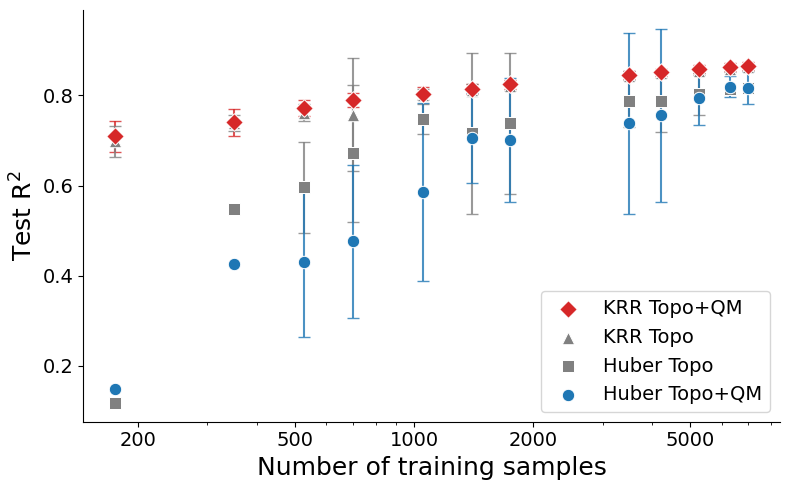

In [317]:
from matplotlib.ticker import LogLocator, ScalarFormatter

model_dfs = {
    "KRR_combo": KRR_combo_df_pos,
    "KRR_topo":  KRR_topo_df_pos,
    "HuberReg_topo":  HuberReg_topo_df_pos,
    "HuberReg_combo": HuberReg_combo_df_pos,
    
}

combined_df = combine_model_dfs(model_dfs, "test_r2")

display(combined_df.filter(regex="mean|std|size", axis=1))

models = [
    ModelConfig(mean_col="KRR_combo_mean", std_col="KRR_combo_std", label="KRR Topo+QM", color="tab:red", marker="D", zorder=4),
    ModelConfig(mean_col="KRR_topo_mean", std_col="KRR_topo_std", label="KRR Topo", color="grey", marker="^", zorder=3),
    ModelConfig(mean_col="HuberReg_topo_mean", std_col="HuberReg_topo_std", label="Huber Topo", color="grey", marker="s", zorder=1),
    ModelConfig(mean_col="HuberReg_combo_mean", std_col="HuberReg_combo_std", label="Huber Topo+QM", color="tab:blue", zorder=2),
]


fig, ax = plt.subplots(figsize=(8, 5))

plot_size_evo(ax, combined_df, models)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=14)
plt.tight_layout()
# plt.savefig("score_evolution_classical.pdf", format="pdf")
plt.show()

,size,chemprop_baseline_mean,chemprop_baseline_std,chemprop_rdkit_mean,chemprop_rdkit_std,chemprop_atom_mean,chemprop_atom_std,chemprop_full_mean,chemprop_full_std
0,0.025,0.640723,0.034979,0.711631,0.034958,0.694783,0.020435,0.351404,1.123589
1,0.050,0.701268,0.036377,0.752711,0.019630,0.735835,0.021259,0.600166,0.603998
2,0.075,0.731178,0.041169,0.768609,0.046072,0.754571,0.017901,0.723433,0.176855
3,0.100,0.748232,0.029990,0.789655,0.016487,0.770599,0.016170,0.760652,0.052419
4,0.150,0.772941,0.032839,0.809545,0.014832,0.790352,0.015678,0.792364,0.021672
5,0.200,0.786076,0.034088,0.821201,0.010689,0.794421,0.029096,0.798851,0.035134
6,0.250,0.797134,0.033477,0.831107,0.013177,0.807069,0.016009,0.787560,0.132581
7,0.500,0.817991,0.023937,0.848749,0.012754,0.830621,0.016233,0.831479,0.029032
8,0.600,0.833820,0.013337,0.858594,0.009000,0.837754,0.016640,0.843172,0.012623
9,0.750,0.845423,0.012188,0.865354,0.009023,0.844202,0.007727,0.847831,0.012831


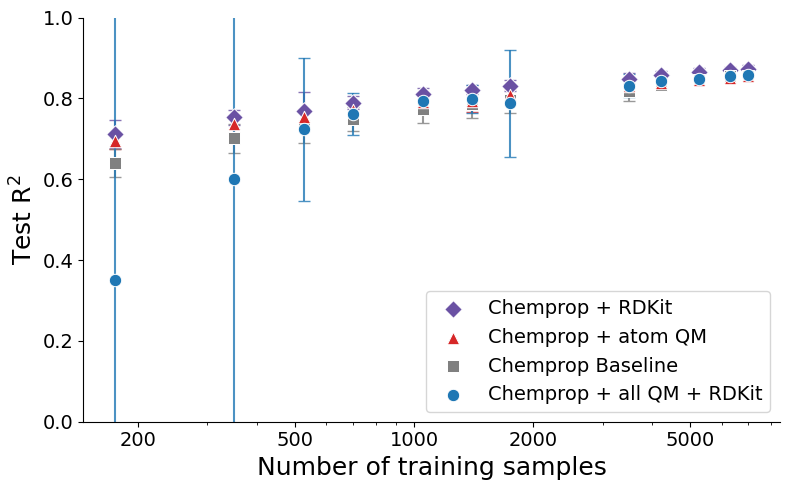

In [316]:
model_dfs = {
    "chemprop_baseline":  chemprop_baseline_df,
    "chemprop_rdkit": chemprop_rdkit_df,
    "chemprop_atom":  chemprop_atom_df,
    "chemprop_full": chemprop_full_df,
    
}

combined_df = combine_model_dfs(model_dfs, "r2_test")

display(combined_df[["size", "chemprop_baseline_mean", "chemprop_baseline_std", "chemprop_rdkit_mean", "chemprop_rdkit_std", "chemprop_atom_mean", "chemprop_atom_std", "chemprop_full_mean", "chemprop_full_std"]])

models = [
    ModelConfig(mean_col="chemprop_rdkit_mean", std_col="chemprop_rdkit_std", label="Chemprop + RDKit", color="#6a51a3", marker="D", zorder=2),
    ModelConfig(mean_col="chemprop_atom_mean", std_col="chemprop_atom_std", label="Chemprop + atom QM", color="tab:red", marker="^", zorder=4),
    ModelConfig(mean_col="chemprop_baseline_mean", std_col="chemprop_baseline_std", label="Chemprop Baseline", color="grey", marker="s", zorder=3),
    ModelConfig(mean_col="chemprop_full_mean", std_col="chemprop_full_std", label="Chemprop + all QM + RDKit", color="tab:blue", zorder=4),
]

fig, ax = plt.subplots(figsize=(8, 5))

plot_size_evo(ax, combined_df, models)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_ylabel(r"Test R$^2$")

plt.ylim(0, 1)

ax.legend(fontsize=14, loc="lower right")
plt.tight_layout()
# plt.savefig("score_evolution_chemprop_allQM.pdf", format="pdf")
plt.show()

### Kernel Ridge Regression

In [29]:
KRR_combined_df = make_combined_df(KRR_combo_filtered_df_pos, KRR_topo_filtered_df_pos, metric="test_r2")
KRR_plot_df = KRR_combined_df.drop([0.025, 0.05, 0.075])
KRR_plot_df

,combo_mean,combo_std,topo_mean,topo_std,diff,num_samples,num_scores
size,,,,,,,
0.10,0.789265,0.012541,0.780930,0.015397,0.008335,876,22
0.15,0.804369,0.012167,0.801830,0.016007,0.002539,1314,25
0.20,0.813814,0.011373,0.811786,0.014081,0.002028,1752,25
0.25,0.822471,0.010408,0.821599,0.010107,0.000872,2190,25
0.50,0.845760,0.010255,0.842313,0.009569,0.003447,4381,25
0.60,0.851780,0.010113,0.847748,0.009233,0.004032,5257,25
0.75,0.859533,0.008503,0.854172,0.009513,0.005362,6572,25
0.90,0.864036,0.007749,0.858985,0.008434,0.005051,7886,25
1.00,0.866426,0.008988,0.861859,0.008829,0.004567,8763,25


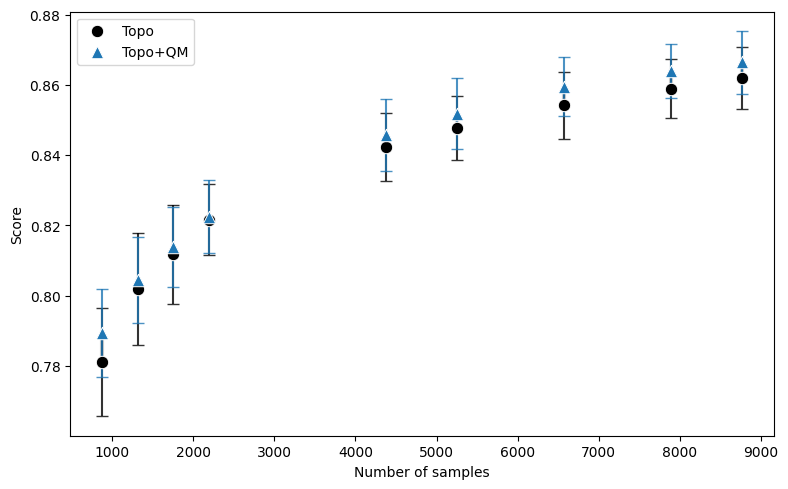

In [30]:
plot_size_evo(KRR_plot_df)
# plt.xscale("log")

Text(0, 0.5, 'Score Difference')

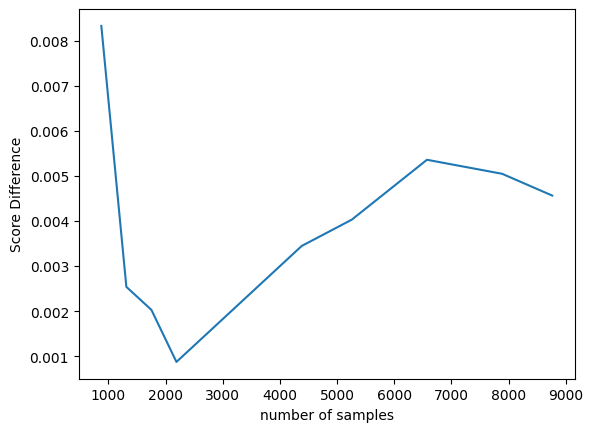

In [227]:
plt.plot(KRR_plot_df["num_samples"], KRR_plot_df["diff"])
plt.xlabel("number of samples")
plt.ylabel("Score Difference")

In [253]:
from math import ceil, floor

krr_combo_groups = KRR_combo_df_pos.groupby("size")
krr_topo_groups = KRR_topo_df_pos.groupby("size")

for size in KRR_plot_df.index:
    print(f"------ {size = } ------")
    n_tot = 8763

    n_train = floor(floor(n_tot * 0.8) * size)
    n_test = ceil(n_tot * 0.2)


    compare(
        krr_combo_groups.get_group(size).reset_index(),
        krr_topo_groups.get_group(size).reset_index(),
        n_train=n_train,
        n_test=n_test
    )

    print("\n\n\n")

------ size = 0.1 ------
KRR_topo+QM mean r2: 0.7768493208993575 (Train: 0.9369255977371105)
KRR_topo mean r2: 0.7747753929916291 (Train: 0.9305058822776664)
Mean improvement: 0.00207392790772841
T-test p-value: 0.7190647327847952 -> not statistically significant
Wilcoxon p-value: 0.3665854334831238 -> not statistically significant


KRR_topo+QM mean MSE: 1.187949903448723 (Train: 0.33444953426828056)
KRR_topo mean MSE: 1.1989339189005588 (Train: 0.3678413135561906)
Mean improvement: -0.0109840154518358
T-test p-value: 0.7196117188366953 -> not statistically significant
Wilcoxon p-value: 0.3809836506843567 -> not statistically significant






------ size = 0.15 ------
KRR_topo+QM mean r2: 0.8037335145991631 (Train: 0.9567898034190432)
KRR_topo mean r2: 0.7980200804218417 (Train: 0.933430654402852)
Mean improvement: 0.00571343417732145
T-test p-value: 0.14189704985367935 -> not statistically significant
Wilcoxon p-value: 0.013554692268371582 -> statistically significant


KRR_topo+QM 

In [261]:
file = Path(r"..\data\KRR_results\2_KRR_combo_rerun_PFI_results.csv")
krr_combo_fi_df = pd.read_csv(file)

display(krr_combo_fi_df[krr_combo_fi_df["fold_id"]==0][krr_combo_fi_df["size"]==0.025])

grouped = krr_combo_fi_df[
    krr_combo_fi_df["fold_id"]
    .isin(KRR_combo_df_pos.fold_id.unique())
    ].groupby("size")

display(grouped.get_group(0.025))

for size in KRR_combo_df_pos["size"].unique():
    print(f"------ {size = } ------")
    
    data = grouped.get_group(size)
    groups = data[["fold_id", "feature", "r2_mean"]]

    FI_dict = {
        fold_id: df.set_index("feature")["r2_mean"]
        for fold_id, df in groups.groupby("fold_id")
    }

    FI = FeatureImportance(
        krr_combo_groups.get_group(size).reset_index(drop=True),
        provided_FI=FI_dict
    )

    fi_df = FI.get_feature_importance(20)
    display(fi_df)

    FI.plot(20)

C:\Users\thibo\AppData\Local\Temp\ipykernel_19324\1594720952.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(krr_combo_fi_df[krr_combo_fi_df["fold_id"]==0][krr_combo_fi_df["size"]==0.025])


,fold_id,size,feature,r2_mean,r2_std,MSE_mean,MSE_std
0,0,0.025,atomization_energy,0.016178,0.006110,0.085662,0.032352
1,0,0.025,homo_lumo_gap,0.003444,0.001827,0.018237,0.009677
2,0,0.025,ionization_energy,-0.001066,0.000315,-0.005647,0.001669
3,0,0.025,electron_affinity,0.000000,0.000000,0.000000,0.000000
4,0,0.025,chemical_potential,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
345,0,0.025,fr_thiazole,-0.000099,0.000414,-0.000527,0.002195
346,0,0.025,fr_thiocyan,0.000000,0.000000,0.000000,0.000000
347,0,0.025,fr_thiophene,-0.002113,0.001462,-0.011191,0.007739
348,0,0.025,fr_unbrch_alkane,0.000000,0.000000,0.000000,0.000000


,fold_id,size,feature,r2_mean,r2_std,MSE_mean,MSE_std
0,0,0.025,atomization_energy,0.016178,0.006110,0.085662,0.032352
1,0,0.025,homo_lumo_gap,0.003444,0.001827,0.018237,0.009677
2,0,0.025,ionization_energy,-0.001066,0.000315,-0.005647,0.001669
3,0,0.025,electron_affinity,0.000000,0.000000,0.000000,0.000000
4,0,0.025,chemical_potential,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
101145,9,0.025,fr_thiazole,0.000000,0.000000,0.000000,0.000000
101146,9,0.025,fr_thiocyan,0.000000,0.000000,0.000000,0.000000
101147,9,0.025,fr_thiophene,0.001705,0.001182,0.008514,0.005901
101148,9,0.025,fr_unbrch_alkane,0.000000,0.000000,0.000000,0.000000


------ size = np.float64(0.025) ------


,feature,frequency,mean_importance,std_importance,score,std_score
0,avg_atomic_dipole_dipole_interaction,0.111111,-6.210716e+09,5.895340e+09,6.900795e+08,6.550378e+08
1,max_atomic_quadrupole_principal_invariant_2,0.111111,-2.720302e+09,2.719047e+09,3.022558e+08,3.021164e+08
2,min_atomic_polarizability_anisotropy,0.222222,1.188598e+09,2.058712e+09,2.641329e+08,4.574916e+08
3,std_effective_coordination_number,0.222222,-7.195012e+08,1.307861e+09,1.598892e+08,2.906357e+08
4,max_atomic_fukui_minus,0.222222,-6.227655e+08,1.140952e+09,1.383923e+08,2.535448e+08
...,...,...,...,...,...,...
101,SMR_VSA1,0.055556,8.691327e-03,0.000000e+00,4.828515e-04,0.000000e+00
102,delta_gibbs_free_energy_300K,0.055556,8.614119e-03,0.000000e+00,4.785622e-04,0.000000e+00
103,fr_barbitur,0.055556,8.338172e-03,0.000000e+00,4.632318e-04,0.000000e+00
104,SMR_VSA2,0.055556,-7.913600e-03,0.000000e+00,4.396445e-04,0.000000e+00


AttributeError: 'int' object has no attribute 'barh'

In [263]:
file = Path(r"..\data\HuberReg_results\2_HuberReg_combo_rerun_PFI_results.csv")
krr_combo_fi_df = pd.read_csv(file)

display(krr_combo_fi_df[krr_combo_fi_df["fold_id"]==0][krr_combo_fi_df["size"]==0.025])

C:\Users\thibo\AppData\Local\Temp\ipykernel_19324\3506116245.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  display(krr_combo_fi_df[krr_combo_fi_df["fold_id"]==0][krr_combo_fi_df["size"]==0.025])


,fold_id,size,feature,r2_mean,r2_std,MSE_mean,MSE_std
0,0,0.025,atomization_energy,0.112521,0.031644,0.595797,0.167553
1,0,0.025,homo_lumo_gap,0.138421,0.131110,0.732941,0.694226
2,0,0.025,ionization_energy,-0.069950,0.101202,-0.370385,0.535866
3,0,0.025,electron_affinity,0.000000,0.000000,0.000000,0.000000
4,0,0.025,chemical_potential,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...
345,0,0.025,fr_thiazole,-0.002522,0.019682,-0.013356,0.104215
346,0,0.025,fr_thiocyan,0.000000,0.000000,0.000000,0.000000
347,0,0.025,fr_thiophene,0.006050,0.005892,0.032036,0.031197
348,0,0.025,fr_unbrch_alkane,0.000000,0.000000,0.000000,0.000000


In [283]:
l = np.array([[0, 0.025], [0, 0.05], [0, 0.075], [0, 0.1], [0, 0.15], [0, 0.2], [0, 0.25], [0, 0.5], [0, 0.6], [0, 0.75], [0, 0.9], [0, 1], [1, 0.025], [1, 0.05], [1, 0.075], [1, 0.1], [1, 0.15], [1, 0.2], [1, 0.25], [1, 0.5], [1, 0.6], [1, 0.75], [1, 0.9], [1, 1], [2, 0.025], [2, 0.05], [2, 0.075], [2, 0.1], [2, 0.15], [2, 0.2], [2, 0.25], [2, 0.5], [2, 0.6], [2, 0.75], [2, 0.9], [2, 1], [3, 0.025], [3, 0.05], [3, 0.075], [3, 0.1], [3, 0.15], [3, 0.2], [3, 0.25], [3, 0.5], [3, 0.6], [3, 0.75], [3, 0.9], [3, 1], [4, 0.025], [4, 0.05], [4, 0.075], [4, 0.1], [4, 0.15], [4, 0.2], [4, 0.25], [4, 0.5], [4, 0.6], [4, 0.75], [4, 0.9], [4, 1], [5, 0.025], [5, 0.05], [5, 0.075], [5, 0.1], [5, 0.15], [5, 0.2], [5, 0.25], [5, 0.5], [5, 0.6], [5, 0.75], [5, 0.9], [5, 1], [6, 0.025], [6, 0.05], [6, 0.075], [6, 0.1], [6, 0.15], [6, 0.2], [6, 0.25], [6, 0.5], [6, 0.6], [6, 0.75], [6, 0.9], [6, 1], [7, 0.025], [7, 0.05], [7, 0.075], [7, 0.1], [7, 0.15], [7, 0.2], [7, 0.25], [7, 0.5], [7, 0.6], [7, 0.75], [7, 0.9], [7, 1], [8, 0.025], [8, 0.05], [8, 0.075], [8, 0.1], [8, 0.15], [8, 0.2], [8, 0.25], [8, 0.5], [8, 0.6], [8, 0.75], [8, 0.9], [8, 1], [9, 0.025], [9, 0.05], [9, 0.075], [9, 0.1], [9, 0.15], [9, 0.2], [9, 0.25], [9, 0.5], [9, 0.6], [9, 0.75], [9, 0.9], [9, 1], [10, 0.025], [10, 0.05], [10, 0.075], [10, 0.1], [10, 0.15], [10, 0.2], [10, 0.25], [10, 0.5], [10, 0.6], [10, 0.75], [10, 0.9], [10, 1], [11, 0.025], [11, 0.05], [11, 0.075], [11, 0.1], [11, 0.15], [11, 0.2], [11, 0.25], [11, 0.5], [11, 0.6], [11, 0.75], [11, 0.9], [11, 1], [12, 0.025], [12, 0.05], [12, 0.075], [12, 0.1], [12, 0.15], [12, 0.2], [12, 0.25], [12, 0.5], [12, 0.6], [12, 0.75], [12, 0.9], [12, 1], [13, 0.025], [13, 0.05], [13, 0.075], [13, 0.1], [13, 0.15], [13, 0.2], [13, 0.25], [13, 0.5], [13, 0.6], [13, 0.75], [13, 0.9], [13, 1], [14, 0.025], [14, 0.05], [14, 0.075], [14, 0.1], [14, 0.15], [14, 0.2], [14, 0.25], [14, 0.5], [14, 0.6], [14, 0.75], [14, 0.9], [14, 1], [15, 0.025], [15, 0.05], [15, 0.075], [15, 0.1], [15, 0.15], [15, 0.2], [15, 0.25], [15, 0.5], [15, 0.6], [15, 0.75], [15, 0.9], [15, 1], [16, 0.025], [16, 0.05], [16, 0.075], [16, 0.1], [16, 0.15], [16, 0.2], [16, 0.25], [16, 0.5], [16, 0.6], [16, 0.75], [16, 0.9], [16, 1], [17, 0.025], [17, 0.05], [17, 0.075], [17, 0.1], [17, 0.15], [17, 0.2], [17, 0.25], [17, 0.5], [17, 0.6], [17, 0.75], [17, 0.9], [17, 1], [18, 0.025], [18, 0.05], [18, 0.075], [18, 0.1], [18, 0.15], [18, 0.2], [18, 0.25], [18, 0.5], [18, 0.6], [18, 0.75], [18, 0.9], [18, 1], [19, 0.025], [19, 0.05], [19, 0.075], [19, 0.1], [19, 0.15], [19, 0.2], [19, 0.25], [19, 0.5], [19, 0.6], [19, 0.75], [19, 0.9], [19, 1], [20, 0.025], [20, 0.05], [20, 0.075], [20, 0.1], [20, 0.15], [20, 0.2], [20, 0.25], [20, 0.5], [20, 0.6], [20, 0.75], [20, 0.9], [20, 1], [21, 0.025], [21, 0.05], [21, 0.075], [21, 0.1], [21, 0.15], [21, 0.2], [21, 0.25], [21, 0.5], [21, 0.6], [21, 0.75], [21, 0.9], [21, 1], [22, 0.025], [22, 0.05], [22, 0.075], [22, 0.1], [22, 0.15], [22, 0.2], [22, 0.25], [22, 0.5], [22, 0.6], [22, 0.75], [22, 0.9], [22, 1], [23, 0.025], [23, 0.05], [23, 0.075], [23, 0.1], [23, 0.15], [23, 0.2], [23, 0.25], [23, 0.5], [23, 0.6], [23, 0.75], [23, 0.9], [23, 1], [24, 0.025], [24, 0.05], [24, 0.075], [24, 0.1], [24, 0.15], [24, 0.2], [24, 0.25], [24, 0.5], [24, 0.6], [24, 0.75], [24, 0.9], [24, 1]])

In [292]:
idx = np.where(l[:, 1] == 0.025)[0]
",".join(map(str, idx))

'0,12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204,216,228,240,252,264,276,288'

In [310]:
l[[0,12,24,36,48,60,72,84,96,108,120,132,144,156,168,180,192,204,216,228,240,252,264,276,288]]

array([[ 0.   ,  0.025],
       [ 1.   ,  0.025],
       [ 2.   ,  0.025],
       [ 3.   ,  0.025],
       [ 4.   ,  0.025],
       [ 5.   ,  0.025],
       [ 6.   ,  0.025],
       [ 7.   ,  0.025],
       [ 8.   ,  0.025],
       [ 9.   ,  0.025],
       [10.   ,  0.025],
       [11.   ,  0.025],
       [12.   ,  0.025],
       [13.   ,  0.025],
       [14.   ,  0.025],
       [15.   ,  0.025],
       [16.   ,  0.025],
       [17.   ,  0.025],
       [18.   ,  0.025],
       [19.   ,  0.025],
       [20.   ,  0.025],
       [21.   ,  0.025],
       [22.   ,  0.025],
       [23.   ,  0.025],
       [24.   ,  0.025]])